In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Work on this Dataset from Kaggle :  Predictive Maintenance Dataset (AI4I 2020)
 https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/data

## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
SEED = 42

In [ ]:
# load the dataset
dataset_path = '/content/predictive-maintenance-dataset-ai4i-2020.csv'
df = pd.read_csv(dataset_path)

In [ ]:
# total number of rows and columns
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")

Number of rows: 10000, Number of columns: 14


In [ ]:
df.replace("?",np.nan,inplace=True)

### The machine failure consists of five independent failure modes:

- tool wear failure (TWF): the tool will be replaced of fail at a randomly selected tool wear time between 200 - 240 mins (120 times in our dataset). At this point in time, the tool is replaced 69 times, and fails 51 times (randomly assigned).
- heat dissipation failure (HDF): heat dissipation causes a process failure, if the difference between air- and process temperature is below 8.6 K and the tools rotational speed is below 1380 rpm. This is the case for 115 data points.
- power failure (PWF): the product of torque and rotational speed (in rad/s) equals the power required for the process. If this power is below 3500 W or above 9000 W, the process fails, which is the case 95 times in our dataset.
- overstrain failure (OSF): if the product of tool wear and torque exceeds 11,000 minNm for the L product variant (12,000 M, 13,000 H), the process fails due to overstrain. This is true for 98 datapoints.
random failures (RNF): each process has a chance of 0,1 % to fail regardless of its process parameters. This is the case for only 5 datapoints, less than could be expected for 10,000 datapoints in  dataset.


If at least one of the above failure modes is true, the process fails and the 'machine failure' label is set to 1. It is therefore not transparent to the machine learning method, which of the failure modes has caused the process to fail.


In [ ]:
df.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
UDI,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64


In [ ]:
df.nunique()

,0
UDI,10000
Product ID,10000
Type,3
Air temperature [K],93
Process temperature [K],82
Rotational speed [rpm],941
Torque [Nm],577
Tool wear [min],246
Machine failure,2
TWF,2


In [ ]:
df['Type'].value_counts()

,count
Type,
L,6000
M,2997
H,1003


## EXPLORATORY DATA ANALYSIS

In [ ]:
print(df.shape)
print(df.columns.tolist())
df.head()

(10000, 14)
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
# rename dataset columns
df.rename(columns = {'Air temperature [K]':'Air temperature',
                     'Process temperature [K]':'Process temperature',
                     'Rotational speed [rpm]':'Rotational speed',
                     'Torque [Nm]':'Torque',
                     'Tool wear [min]':'Tool wear'},
          inplace = True)

In [ ]:
# drop UDI and Product ID columns
df.drop(['Product ID', 'UDI'], axis=1, inplace = True)

In [ ]:
df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature,10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature,10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed,10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque,10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear,10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,NaN,NaN,NaN,0.0115,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,NaN,NaN,NaN,0.0095,0.097009,0.0,0.0,0.0,0.0,1.0


In [ ]:
df.info() # there are no null values, as it turns out

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB


In [ ]:
# overall descriptive information on numerical attributes
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Air temperature,10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature,10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed,10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque,10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear,10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.0,0.0,0.0,1.0
OSF,10000.0,0.00980,0.098514,0.0,0.0,0.0,0.0,1.0


In [ ]:
# overall descriptive information on categorical attributes
df_categorical = df.select_dtypes(include=[np.object_])
df_categorical.describe().transpose()

,count,unique,top,freq
Type,10000,3,L,6000


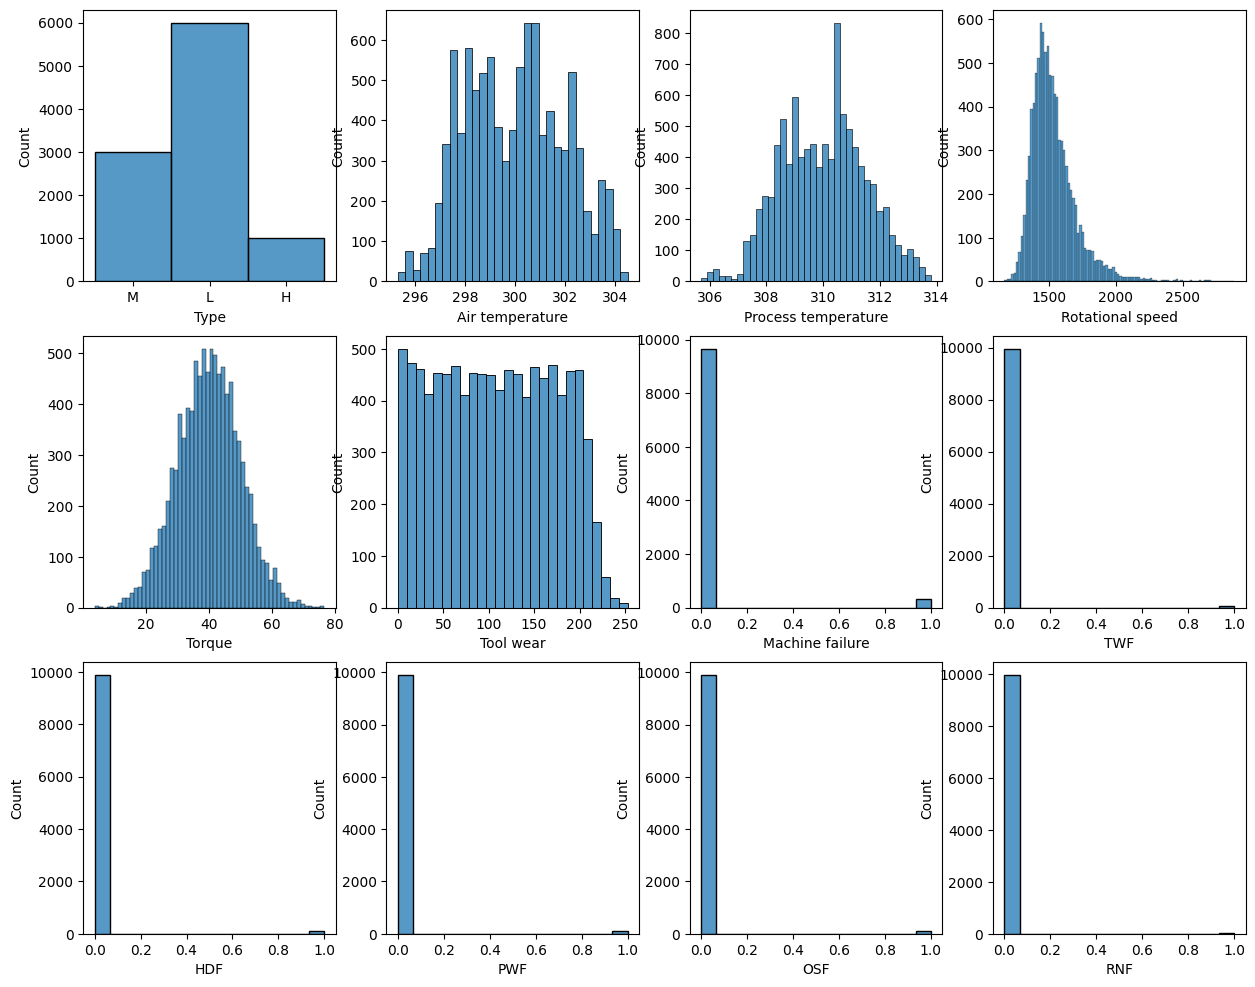

In [ ]:
# Plot the distribution for each attribute,
# We can see that the data is imbalanced (Type, Machine failure, TWF, HDF, PWF, OSF, RNF)
fig, ax = plt.subplots(3, 4, figsize=(15,12))

for i, col in enumerate(df.columns):
    sns.histplot(df[col], ax=ax[i//4][i%4])

In [ ]:
df_failures = df.loc[:, ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']]

In [ ]:
# Calculate the sum of the values in each row
rows_sum = df_failures.sum(axis=1)

Text(0.5, 1.0, 'Number of failure types per record')

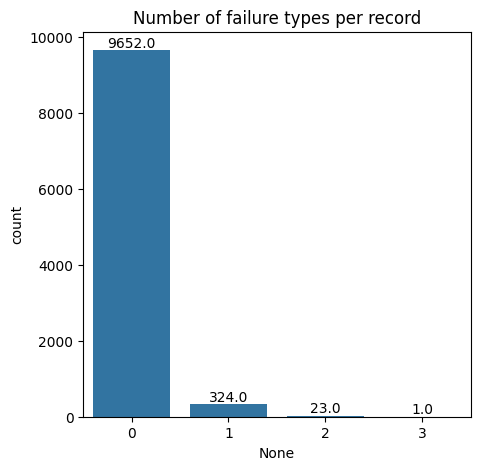

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.countplot(x=rows_sum, ax=ax)
for patch in ax.patches:
    ax.annotate(str(patch.get_height()), (patch.get_x() + patch.get_width()/2, patch.get_height()), ha='center', va='bottom')
ax.set_title('Number of failure types per record')

As shown above, 24 records contain more than one type of failure, but their count is very small compared to the entire data set.

In [ ]:
for column in df.columns:
    try:
        df[column]=df[column].astype(float)
    except:
        pass

In [ ]:
# show the numeric characters
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Air temperature,10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature,10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed,10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque,10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear,10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.0,0.0,0.0,1.0
OSF,10000.0,0.00980,0.098514,0.0,0.0,0.0,0.0,1.0


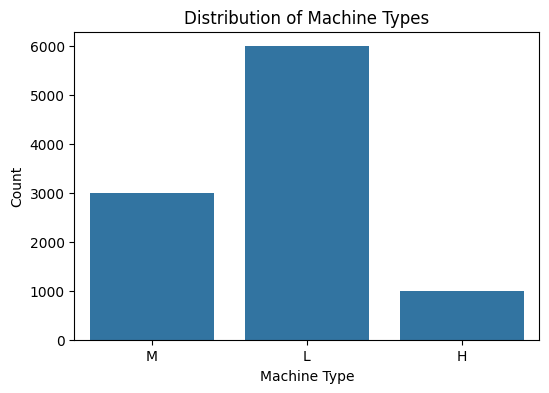

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Type', data=df)
plt.title('Distribution of Machine Types')
plt.xlabel('Machine Type')
plt.ylabel('Count')
plt.show()

In [ ]:
label_cols_full = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

In [ ]:
print("Positive counts per label:")
print(df[label_cols_full].sum())

Positive counts per label:
Machine failure    339.0
TWF                 46.0
HDF                115.0
PWF                 95.0
OSF                 98.0
RNF                 19.0
dtype: float64


In [ ]:
print("\nPositive rate per label:")
print(df[label_cols_full].mean().round(4))


Positive rate per label:
Machine failure    0.0339
TWF                0.0046
HDF                0.0115
PWF                0.0095
OSF                0.0098
RNF                0.0019
dtype: float64


In [ ]:
print(df.describe().T)

                       count        mean         std     min     25%     50%  \
Air temperature      10000.0   300.00493    2.000259   295.3   298.3   300.1   
Process temperature  10000.0   310.00556    1.483734   305.7   308.8   310.1   
Rotational speed     10000.0  1538.77610  179.284096  1168.0  1423.0  1503.0   
Torque               10000.0    39.98691    9.968934     3.8    33.2    40.1   
Tool wear            10000.0   107.95100   63.654147     0.0    53.0   108.0   
Machine failure      10000.0     0.03390    0.180981     0.0     0.0     0.0   
TWF                  10000.0     0.00460    0.067671     0.0     0.0     0.0   
HDF                  10000.0     0.01150    0.106625     0.0     0.0     0.0   
PWF                  10000.0     0.00950    0.097009     0.0     0.0     0.0   
OSF                  10000.0     0.00980    0.098514     0.0     0.0     0.0   
RNF                  10000.0     0.00190    0.043550     0.0     0.0     0.0   

                        75%     max  
A

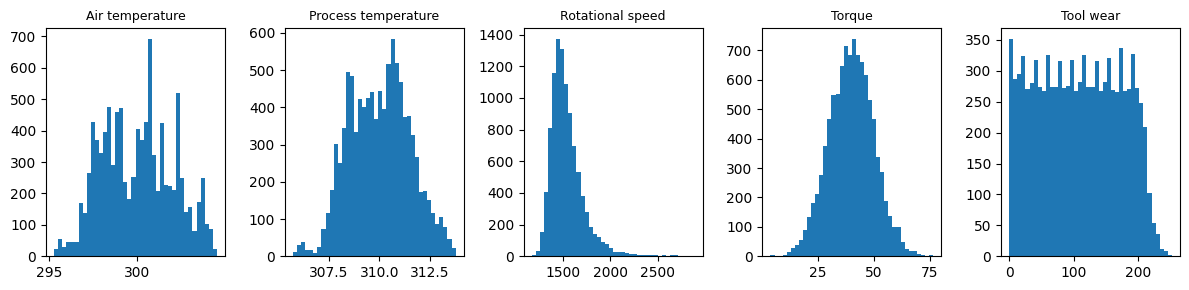

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
numeric_cols = ['Air temperature', 'Process temperature',
                 'Rotational speed', 'Torque', 'Tool wear']
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins=40)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()


## FEATURE ENGINEERING

Drop identifiers, one-hot encode Type, derive physics-informed features
from the failure-generation rules described in the dataset documentation.


One-hot encode Type (L / M / H). No natural ordinal relationship for an MLP,
so one-hot is safer than an arbitrary ordinal mapping.


df = df.drop(columns=['UDI', 'Product ID'])

In [ ]:
if 'Type' in df.columns:
    df = pd.get_dummies(df, columns=['Type'], prefix='Type')
type_cols = [c for c in df.columns if c.startswith('Type_')]
df[type_cols] = df[type_cols].astype(np.float32)

Physics-informed derived features, matching the exact rules used to
synthetically generate each failure mode. NOTE: these will make PWF, OSF
and HDF easier than they would be on real sensor data, since the dataset
rules are near-deterministic functions of these exact quantities.

In [ ]:
df['Power'] = df['Torque'] * df['Rotational speed'] * (2 * np.pi / 60)
df['Torque_x_ToolWear'] = df['Torque'] * df['Tool wear']
df['Temp_Diff'] = df['Process temperature'] - df['Air temperature']

In [ ]:
# Drop RNF: purely stochastic (0.1% independent probability per the docs),
# not a learnable pattern. Keep Machine failure + the 4 remaining modes.
label_cols = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF']
df = df.drop(columns=['RNF'])

In [ ]:
feature_cols = [c for c in df.columns if c not in label_cols]

In [ ]:
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Labels ({len(label_cols)}): {label_cols}")

Features (11): ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Type_H', 'Type_L', 'Type_M', 'Power', 'Torque_x_ToolWear', 'Temp_Diff']
Labels (5): ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF']


In [ ]:
print(label_cols)

['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF']


## Multilabel stratified split
Standard train_test_split does not stratify multi-label targets well.
With OSF/PWF/HDF at ~100 positive rows out of 10000, a naive random split
risks a head having near-zero positives in val or test.

In [ ]:
!pip install iterative-stratification

In [ ]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

In [ ]:
X = df[feature_cols].values.astype(np.float32)
Y = df[label_cols].values.astype(np.float32)

In [ ]:
# first split: 70% train, 30% temp
msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(msss1.split(X, Y))

In [ ]:
X_train, Y_train = X[train_idx], Y[train_idx]
X_temp, Y_temp = X[temp_idx], Y[temp_idx]

In [ ]:
# second split: temp -> 1/3 val, 2/3 test (gives 70/10/20 overall)
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=(1/3), random_state=SEED)
val_idx, test_idx = next(msss2.split(X_temp, Y_temp))
# Stratify dataset splitting

In [ ]:
X_val, Y_val = X_temp[val_idx], Y_temp[val_idx]
X_test, Y_test = X_temp[test_idx], Y_temp[test_idx]

In [ ]:
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (7000, 11) | Val: (2000, 11) | Test: (1000, 11)


In [ ]:
print("Positive counts per split (rows, not %):")
for name, Yset in [("train", Y_train), ("val", Y_val), ("test", Y_test)]:

    print(f"{name}: {Yset.sum(axis=0).astype(int).tolist()}  ({label_cols})")


Positive counts per split (rows, not %):
train: [237, 32, 81, 67, 69]  (['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF'])
val: [68, 9, 23, 19, 19]  (['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF'])
test: [34, 5, 11, 9, 10]  (['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF'])


In [ ]:
# Fit StandardScaler on train only, to avoid leakage into val/test.
# One-hot columns don't strictly need scaling but scaling them is harmless
# and keeps the pipeline simple (single scaler for all numeric input dims).
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
## Tensors and DataLoaders
import torch
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
def make_loader(X, Y, batch_size, shuffle):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(Y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

In [ ]:
BATCH_SIZE = 64

In [ ]:
train_loader = make_loader(X_train_scaled.astype(np.float32), Y_train, BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val_scaled.astype(np.float32), Y_val, BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test_scaled.astype(np.float32), Y_test, BATCH_SIZE, shuffle=False)


In [ ]:
print(f"Input dim: {X_train_scaled.shape[1]}")
print(f"Output dim: {Y_train.shape[1]} (labels: {label_cols})")

Input dim: 11
Output dim: 5 (labels: ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF'])


In [ ]:
import random

In [ ]:
print(df.columns.tolist())

['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'Type_H', 'Type_L', 'Type_M', 'Power', 'Torque_x_ToolWear', 'Temp_Diff']


## Training SetUP

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [ ]:
print(label_cols)

['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF']


In [ ]:
CFG = {
    "input_dim": X_train_scaled.shape[1],   # 11
    "hidden_dims": (64, 32),
    "n_outputs": Y_train.shape[1],  # 5, NUNCA hardcodear
    "dropout": 0.2,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 150,
    "patience": 20,
    "batch_size": 64,
}

## Model Class  MLP

In [ ]:
class MachineHealthMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_outputs, dropout):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, n_outputs))  # logits crudos
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## Buildup the model

In [ ]:
model = MachineHealthMLP(
    input_dim=CFG["input_dim"],
    hidden_dims=CFG["hidden_dims"],
    n_outputs=CFG["n_outputs"],
    dropout=CFG["dropout"],
).to(DEVICE)

In [ ]:
n_params = sum(p.numel() for p in model.parameters())

In [ ]:
print(model)
print(f"Parametrers: {n_params:,}")

MachineHealthMLP(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=5, bias=True)
  )
)
Parametrers: 3,205


## Loss con pos_weight gotten from ETL  to Train

In [ ]:
pos_counts = Y_train.sum(axis=0)
neg_counts = len(Y_train) - pos_counts

In [ ]:
pos_weight = torch.tensor(neg_counts / pos_counts, dtype=torch.float32).to(DEVICE)
print(f"pos_weight por clase {label_cols}: {pos_weight.cpu().numpy()}")

pos_weight por clase ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF']: [ 28.535866 217.75      85.419754 103.477615 100.44927 ]


In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=1e-6)


## Training Loop  + Early-Stopping setup

In [ ]:
def eval_epoch(model, loader, criterion):

    model.eval()
    total, n = 0.0, 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = criterion(model(xb), yb)
            total += loss.item() * xb.size(0)
            n += xb.size(0)

    return total / n


In [ ]:
best_val = float("inf")
best_state = None
patience_counter = 0
history = {"train": [], "val": []}

## Main Loop

In [ ]:
for epoch in range(1, CFG["epochs"] + 1):
    model.train()
    total, n = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0)
        n += xb.size(0)

    train_loss = total / n
    val_loss = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Ep {epoch:03d} | train {train_loss:.5f} | val {val_loss:.5f} | lr {lr_now:.2e}")

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= CFG["patience"]:
            print(f"Early stopping en epoch {epoch} (best val {best_val:.5f})")
            break


Ep 001 | train 1.14408 | val 0.92113 | lr 1.00e-03
Ep 005 | train 0.51793 | val 0.44811 | lr 9.97e-04
Ep 010 | train 0.39040 | val 0.31544 | lr 9.89e-04
Ep 015 | train 0.32273 | val 0.29229 | lr 9.76e-04
Ep 020 | train 0.32727 | val 0.28524 | lr 9.57e-04
Ep 025 | train 0.31523 | val 0.26312 | lr 9.33e-04
Ep 030 | train 0.30126 | val 0.29932 | lr 9.05e-04
Ep 035 | train 0.27933 | val 0.26898 | lr 8.72e-04
Ep 040 | train 0.25251 | val 0.28967 | lr 8.35e-04
Ep 045 | train 0.26018 | val 0.29557 | lr 7.94e-04
Ep 050 | train 0.26058 | val 0.26159 | lr 7.50e-04
Ep 055 | train 0.26321 | val 0.27353 | lr 7.04e-04
Ep 060 | train 0.25362 | val 0.27148 | lr 6.55e-04
Ep 065 | train 0.24817 | val 0.27962 | lr 6.04e-04
Ep 070 | train 0.25353 | val 0.25337 | lr 5.53e-04
Ep 075 | train 0.24390 | val 0.26390 | lr 5.00e-04
Ep 080 | train 0.24579 | val 0.27082 | lr 4.48e-04
Ep 085 | train 0.22005 | val 0.30520 | lr 3.97e-04
Early stopping en epoch 86 (best val 0.24161)


In [ ]:
model.load_state_dict(best_state)
print(f"Best val loss: {best_val:.5f}")

Best val loss: 0.24161


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

In [ ]:
def predict_all(model, loader):
    model.eval()
    probs_all, trues_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            probs_all.append(probs)
            trues_all.append(yb.numpy())
    return np.concatenate(probs_all), np.concatenate(trues_all)

In [ ]:
probs_test, y_test_true = predict_all(model, test_loader)
preds_test = (probs_test > 0.5).astype(int)

In [ ]:
print(f"{'Label':<18} {'Precision':<10} {'Recall':<10} {'F1':<10} {'AUC':<10} {'N_pos_test':<10}")
print("-" * 68)
for i, name in enumerate(label_cols):
    p, r, f1, _ = precision_recall_fscore_support(
        y_test_true[:, i], preds_test[:, i], average="binary", zero_division=0
    )
    try:
        auc = roc_auc_score(y_test_true[:, i], probs_test[:, i])
    except ValueError:
        auc = float("nan")
    n_pos = int(y_test_true[:, i].sum())
    print(f"{name:<18} {p:<10.3f} {r:<10.3f} {f1:<10.3f} {auc:<10.3f} {n_pos:<10}")


Label              Precision  Recall     F1         AUC        N_pos_test
--------------------------------------------------------------------
Machine failure    0.294      0.882      0.441      0.975      34        
TWF                0.044      0.800      0.083      0.960      5         
HDF                0.355      1.000      0.524      0.998      11        
PWF                0.231      1.000      0.375      0.999      9         
OSF                0.294      1.000      0.455      1.000      10        


In [ ]:
mode_preds = preds_test[:, 1:]  # TWF, HDF, PWF, OSF
machine_failure_forced = (preds_test[:, 0] == 1) | (mode_preds.any(axis=1))
inconsistencias = (machine_failure_forced != (preds_test[:, 0] == 1)).sum()

In [ ]:
print(f"\nFilas donde Machine_failure predicho no coincide con OR de los modos: {inconsistencias}")


Filas donde Machine_failure predicho no coincide con OR de los modos: 68


In [ ]:
MIN_RECALL = 0.85

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
##  DOuble-Ensure Trained MLP
probs_val, y_val_true = predict_all(model, val_loader)

In [ ]:
## Set up Best Threshold
best_thresholds_business = {}
for i, name in enumerate(label_cols):
    precisions, recalls, thresholds = precision_recall_curve(y_val_true[:, i], probs_val[:, i])
    valid = recalls[:-1] >= MIN_RECALL
    if valid.sum() == 0:
        # no threshold works
        best_idx = np.argmax(recalls[:-1])
    else:
        f1_valid = 2 * precisions[:-1][valid] * recalls[:-1][valid] / (precisions[:-1][valid] + recalls[:-1][valid] + 1e-8)
        best_idx = np.where(valid)[0][np.argmax(f1_valid)]
    best_thresholds_business[name] = float(thresholds[best_idx])
    print(f"{name:<18} umbral: {thresholds[best_idx]:.3f}  precision: {precisions[:-1][best_idx]:.3f}  recall: {recalls[:-1][best_idx]:.3f}")

Machine failure    umbral: 0.749  precision: 0.423  recall: 0.853
TWF                umbral: 0.611  precision: 0.046  recall: 0.889
HDF                umbral: 0.942  precision: 0.724  recall: 0.913
PWF                umbral: 0.988  precision: 0.750  recall: 0.947
OSF                umbral: 0.987  precision: 0.944  recall: 0.895


## Export model to onnx

In [ ]:
!pip install onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 33.8 MB/s eta 0:00:00


In [ ]:
import json
import numpy as np
import torch
import torch.nn as nn
import onnx
import onnxruntime as ort

In [ ]:
class MachineHealthMLPInference(nn.Module):
    def __init__(self, trained_model):
        super().__init__()
        self.net = trained_model.net

    def forward(self, x):
        logits = self.net(x)
        return torch.sigmoid(logits)

In [ ]:
model.eval()
inference_model = MachineHealthMLPInference(model)
inference_model.eval()

MachineHealthMLPInference(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=5, bias=True)
  )
)

In [ ]:
INPUT_DIM = CFG["input_dim"]  # 11
dummy_input = torch.randn(1, INPUT_DIM, dtype=torch.float32).to(DEVICE)

In [ ]:
onnx_path = "checkpoints/piper_machine_health_v1.onnx"

In [ ]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 9.9 MB/s eta 0:00:00


In [ ]:
torch.onnx.export(
    inference_model,
    dummy_input,
    onnx_path,
    input_names=["features"],
    output_names=["failure_probs"],
    dynamic_axes={
        "features": {0: "batch_size"},
        "failure_probs": {0: "batch_size"},
    },
    opset_version=17,
    do_constant_folding=True,
    dynamo=False,
)

/tmp/ipykernel_5743/3176363381.py:1: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [ ]:
print(f"Model in  {onnx_path}")

Model in  checkpoints/piper_machine_health_v1.onnx


In [ ]:
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)
print("Good onnx model")


Good onnx model


In [ ]:
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])

In [ ]:
sample_np = X_test_scaled[:5].astype(np.float32)

In [ ]:
with torch.no_grad():
    torch_out = inference_model(torch.from_numpy(sample_np).to(DEVICE)).cpu().numpy()

In [ ]:
onnx_out = sess.run(None, {"features": sample_np})[0]

In [ ]:
max_diff = np.abs(torch_out - onnx_out).max()
print(f"Diferencia maxima PyTorch vs ONNX: {max_diff:.8f}")
assert max_diff < 1e-5, "Las salidas no coinciden, revisar exportacion"
print("Verificacion OK: ONNX replica exactamente el modelo PyTorch")

Diferencia maxima PyTorch vs ONNX: 0.00000006
Verificacion OK: ONNX replica exactamente el modelo PyTorch


In [ ]:
metadata = {
    "label_order": label_cols,
    "thresholds": best_thresholds_business,
    "feature_order": feature_cols,
    "notes": {
        "TWF": "Really bad low score in test (~0.05)."
    },
}

In [ ]:
onnx_model = onnx.load(onnx_path)
meta = onnx_model.metadata_props.add()
meta.key = "piper_machine_health_metadata"
meta.value = json.dumps(metadata)
onnx.save(onnx_model, onnx_path)

In [ ]:
print(json.dumps(metadata, indent=2))

{
  "label_order": [
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF"
  ],
  "thresholds": {
    "Machine failure": 0.7493606805801392,
    "TWF": 0.6113549470901489,
    "HDF": 0.9416936635971069,
    "PWF": 0.9877787232398987,
    "OSF": 0.9866945743560791
  },
  "feature_order": [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
    "Type_H",
    "Type_L",
    "Type_M",
    "Power",
    "Torque_x_ToolWear",
    "Temp_Diff"
  ],
  "notes": {
    "TWF": "Really bad low score in test (~0.05)."
  }
}


In [ ]:
scaler_params = {
    "feature_order": feature_cols,
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
}


In [ ]:
with open("checkpoints/piper_machine_health_scaler.json", "w") as f:
    json.dump(scaler_params, f, indent=2)

In [ ]:
print("Scaler exportado a checkpoints/piper_machine_health_scaler.json")
print(json.dumps(scaler_params, indent=2)[:300], "...")

Scaler exportado a checkpoints/piper_machine_health_scaler.json
{
  "feature_order": [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear",
    "Type_H",
    "Type_L",
    "Type_M",
    "Power",
    "Torque_x_ToolWear",
    "Temp_Diff"
  ],
  "mean": [
    300.01352835518975,
    310.01610017177035,
    1539.35 ...


In [ ]:
!cp -r /content/checkpoints/  /content/drive/MyDrive/hardware-store/